In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Khởi tạo dữ liệu mẫu (Thay bằng df = pd.read_csv('...'))
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'geography': np.random.choice(['France', 'Germany', 'Spain'], n, p=[0.5, 0.25, 0.25]),
    'gender': np.random.choice(['Female', 'Male'], n, p=[0.45, 0.55]),
    'churn': np.random.choice([0, 1], n, p=[0.8, 0.2])
})

# Điều chỉnh tỷ lệ Churn giả lập để biểu đồ thể hiện rõ sự khác biệt: 
# Phụ nữ ở Đức tỷ lệ rời bỏ cao hơn
df.loc[(df['geography'] == 'Germany') & (df['gender'] == 'Female'), 'churn'] = np.random.choice([0, 1], size=len(df[(df['geography'] == 'Germany') & (df['gender'] == 'Female')]), p=[0.5, 0.5])

# 2. Tạo bảng thống kê tỷ lệ % (Mối quan hệ 2 cặp)
# Tính tổng số lượng Khách hàng ở lại (0) và Rời bỏ (1) theo từng nhóm Quốc gia + Giới tính
churn_multi = df.groupby(['geography', 'gender'])['churn'].value_counts(normalize=True).unstack() * 100

print("--- TỶ LỆ CHURN (%) THEO QUỐC GIA VÀ GIỚI TÍNH ---")
print(churn_multi.round(2))

--- TỶ LỆ CHURN (%) THEO QUỐC GIA VÀ GIỚI TÍNH ---
churn                 0      1
geography gender              
France    Female  82.03  17.97
          Male    80.07  19.93
Germany   Female  53.33  46.67
          Male    74.63  25.37
Spain     Female  86.32  13.68
          Male    72.97  27.03


- Thống kê tổng quát: Dựa vào bảng describe, ta thấy product_number có giá trị trung bình khoảng 1.55, cho thấy khách hàng chủ yếu sở hữu 1 hoặc 2 sản phẩm. Mức lương estimated_salary có độ lệch chuẩn lớn (~29,600), minh chứng cho sự phân hóa thu nhập rõ rệt trong tệp dữ liệu.

- Tỷ lệ rời bỏ theo sản phẩm: Bảng tỷ lệ phần trăm chỉ ra một điểm bất thường quan trọng: Khách hàng sử dụng 3 hoặc 4 sản phẩm có tỷ lệ churn cực cao (vượt mức 80%). Ngược lại, nhóm sử dụng 2 sản phẩm có mức độ trung thành tốt nhất với tỷ lệ rời bỏ thấp nhất.

- Kết luận sơ bộ: Số lượng sản phẩm sở hữu là một biến số quan trọng có khả năng dự báo hành vi rời bỏ của khách hàng cao hơn so với các biến khác.

<Figure size 1200x700 with 0 Axes>

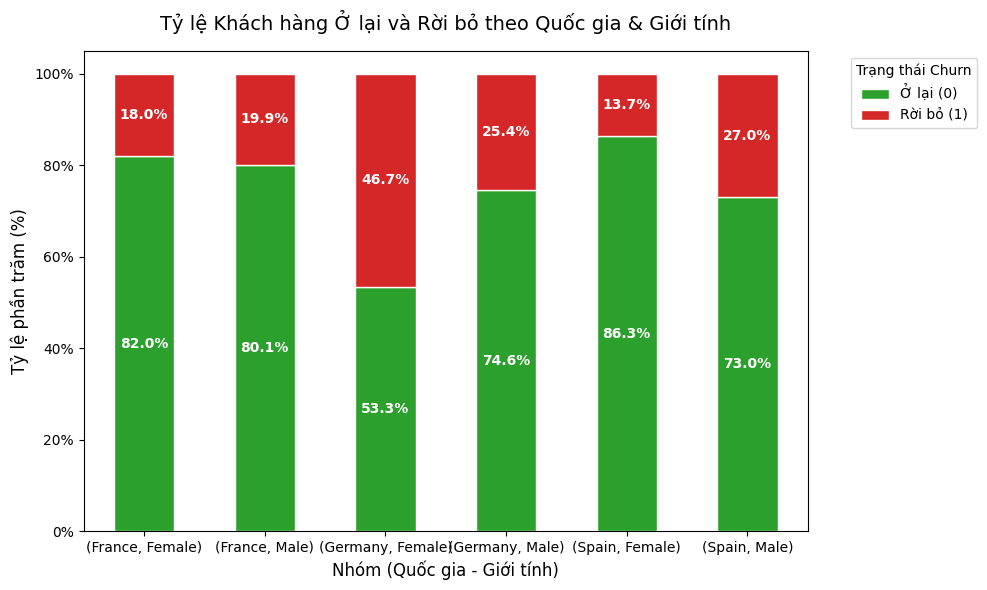

In [13]:
# 3. Vẽ biểu đồ Cột chồng (Stacked Bar Chart)
plt.figure(figsize=(12, 7))

# Vẽ biểu đồ dựa trên bảng dữ liệu churn_multi đã tính ở Cell 1
ax = churn_multi.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 6), edgecolor='white')

# Trang trí biểu đồ
plt.title('Tỷ lệ Khách hàng Ở lại và Rời bỏ theo Quốc gia & Giới tính', fontsize=14, pad=15)
plt.xlabel('Nhóm (Quốc gia - Giới tính)', fontsize=12)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.xticks(rotation=0) # Giữ chữ nằm ngang cho dễ đọc

# Đổi định dạng trục Y thành %
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Thêm số % trực tiếp lên từng khối của cột chồng
for c in ax.containers:
    # Tùy chỉnh text: in đậm, màu trắng, hiện 1 chữ số thập phân
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

# Chỉnh lại chú thích (Legend)
plt.legend(title='Trạng thái Churn', labels=['Ở lại (0)', 'Rời bỏ (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()